# 🔍 Diagnóstico Automático de Series de Tiempo
### ¿Qué modelo usar dada una serie de tiempo?

Este notebook analiza una serie de tiempo y recomienda automáticamente el modelo más adecuado.

**Flujo de análisis:**
```
Serie Original
    ├── ¿Estacionaria? (ADF, KPSS, PP)
    ├── ¿Tiene estacionalidad? (STL, ACF estacional)
    ├── ¿Tiene outliers?
    ├── ACF / PACF  →  AR, MA, ARMA, ARIMA, SARIMA
    ├── Retornos → ¿Ruido blanco? (Ljung-Box)
    └── Retornos² → ¿Efecto ARCH? → GARCH
```

## 0. Instalación de dependencias

In [22]:
#!pip install statsmodels arch pandas numpy matplotlib seaborn scipy yfinance -q

## 1. Importaciones

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estadísticos
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.stattools import q_stat, acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model
from scipy import stats

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 2. Carga de datos

**Opciones:**
- Opción A: Descargar datos financieros con `yfinance`
- Opción B: Cargar tu propio CSV
- Opción C: Generar serie sintética para pruebas

In [24]:
# ============================================================
# ELIGE UNA OPCIÓN
# ============================================================

OPCION = 'A'  # Cambia a 'B' o 'C' según necesites

# ---- OPCIÓN A: Datos financieros ----
if OPCION == 'A':
    import yfinance as yf
    TICKER  = 'PLTR'   # Cambia: 'AAPL', 'EURUSD=X', 'GC=F' (oro), etc.
    PERIODO = '3y'        # '1y', '2y', '5y', 'max'
    raw = yf.download(TICKER, period=PERIODO, auto_adjust=True)[['Close']]
    serie = raw['Close'].dropna()
    serie.name = TICKER
    print(f'✅ Datos descargados: {TICKER} — {len(serie)} observaciones')

# ---- OPCIÓN B: CSV propio ----
elif OPCION == 'B':
    RUTA_CSV    = 'tu_archivo.csv'   # <-- cambia esta ruta
    COLUMNA     = 'valor'            # <-- nombre de la columna con la serie
    COLUMNA_DT  = 'fecha'            # <-- nombre de la columna de fechas (o None)
    df = pd.read_csv(RUTA_CSV, parse_dates=[COLUMNA_DT] if COLUMNA_DT else False)
    if COLUMNA_DT:
        df = df.set_index(COLUMNA_DT)
    serie = df[COLUMNA].dropna()
    print(f'✅ CSV cargado — {len(serie)} observaciones')

# ---- OPCIÓN C: Serie sintética ----
elif OPCION == 'C':
    np.random.seed(42)
    n = 500
    # AR(1) con ruido ARCH
    eps = np.zeros(n)
    h   = np.ones(n)
    for t in range(1, n):
        h[t]   = 0.1 + 0.15 * eps[t-1]**2 + 0.75 * h[t-1]
        eps[t] = np.sqrt(h[t]) * np.random.randn()
    precio = 100 + np.cumsum(eps)
    idx    = pd.date_range('2020-01-01', periods=n, freq='D')
    serie  = pd.Series(precio, index=idx, name='Serie_Sintetica')
    print(f'✅ Serie sintética generada — {len(serie)} observaciones')

# Vista previa
print(f'Período: {serie.index[0].date()} → {serie.index[-1].date()}')
print(f'Media: {serie.mean()[0]:.4f} | Std: {serie.std()[0]:.4f} | Min: {serie.min()[0]:.4f} | Max: {serie.max()[0]:.4f}')

[*********************100%***********************]  1 of 1 completed

✅ Datos descargados: PLTR — 751 observaciones
Período: 2023-03-17 → 2026-03-16
Media: 71.2346 | Std: 62.4677 | Min: 7.3800 | Max: 207.1800


## 3. Vista general de la serie

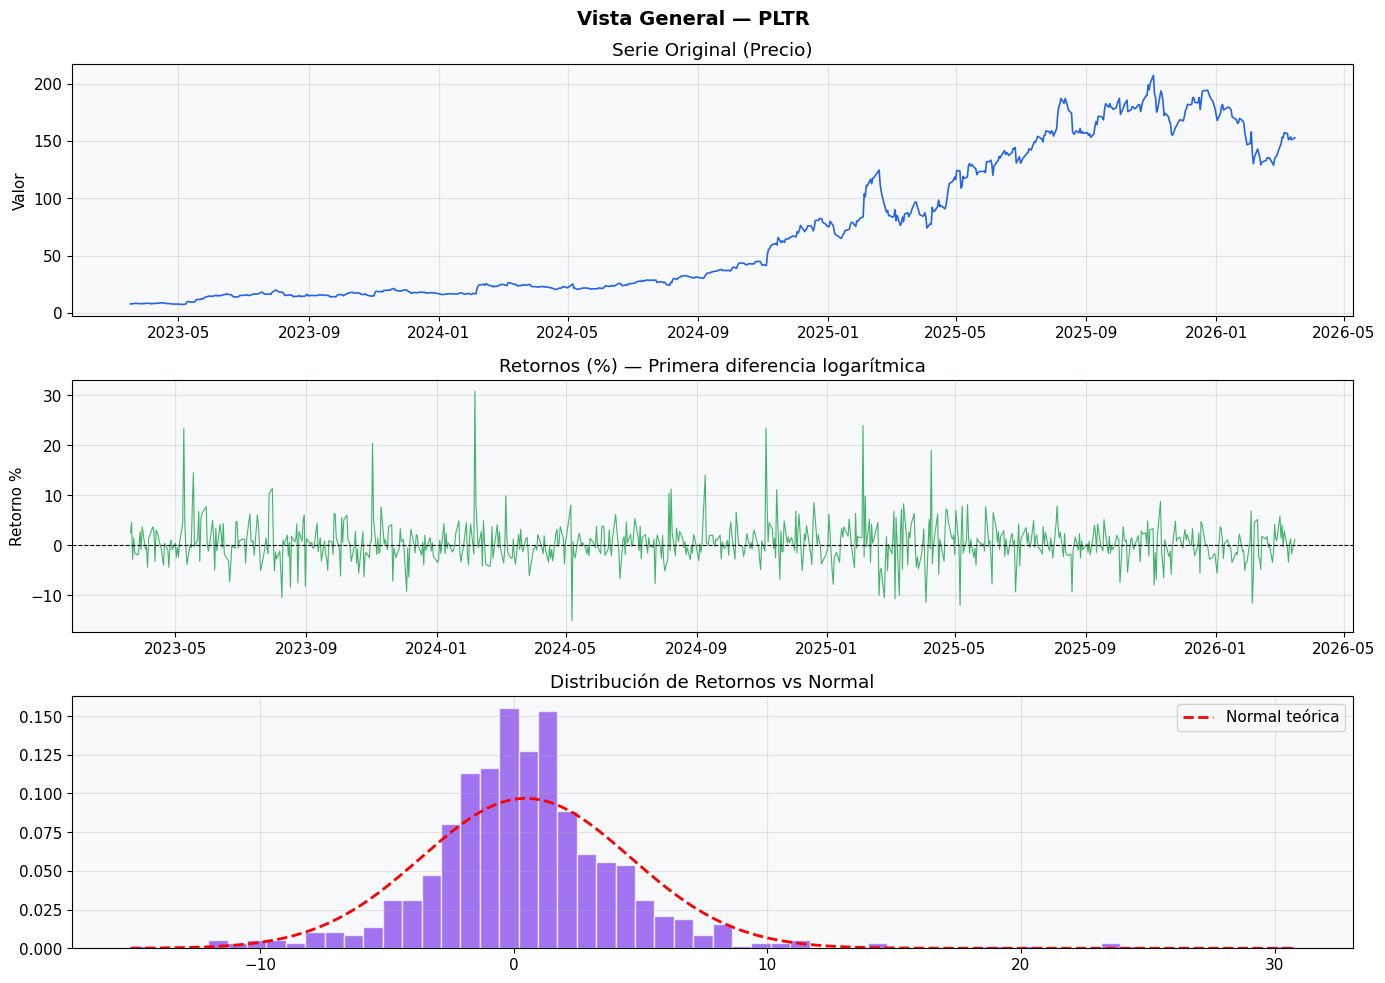

In [25]:
def plot_serie_general(serie):
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    fig.suptitle(f'Vista General — {serie.name}', fontsize=14, fontweight='bold')

    # Precio
    axes[0].plot(serie, color='#2563eb', linewidth=1.2)
    axes[0].set_title('Serie Original (Precio)')
    axes[0].set_ylabel('Valor')

    # Retornos
    retornos = serie.pct_change().dropna() * 100
    axes[1].plot(retornos, color='#16a34a', linewidth=0.8, alpha=0.8)
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_title('Retornos (%) — Primera diferencia logarítmica')
    axes[1].set_ylabel('Retorno %')

    # Histograma de retornos
    axes[2].hist(retornos, bins=60, color='#7c3aed', alpha=0.7, density=True, edgecolor='white')
    # Curva normal de referencia
    x = np.linspace(retornos.min(), retornos.max(), 200)
    axes[2].plot(x, stats.norm.pdf(x, retornos.mean(), retornos.std()),
                 'r--', linewidth=2, label='Normal teórica')
    axes[2].set_title('Distribución de Retornos vs Normal')
    axes[2].legend()

    plt.tight_layout()
    plt.show()
    return retornos

retornos = plot_serie_general(serie)

## 4. Test de Estacionariedad

Usamos **3 tests** para un diagnóstico robusto:
- **ADF** (Augmented Dickey-Fuller): H0 = tiene raíz unitaria (no estacionaria)
- **KPSS**: H0 = ES estacionaria (hipótesis inversa al ADF)
- **Phillips-Perron** (via ADF con más lags): complementario al ADF

In [26]:
def test_estacionariedad(serie, nombre='Serie'):
    print(f"\n{'='*60}")
    print(f'  TESTS DE ESTACIONARIEDAD — {nombre}')
    print(f"{'='*60}")

    resultados = {}

    # --- ADF ---
    adf_res = adfuller(serie.dropna(), autolag='AIC')
    adf_stat, adf_p = adf_res[0], adf_res[1]
    adf_est = '✅ ESTACIONARIA' if adf_p < 0.05 else '❌ NO ESTACIONARIA'
    print(f'\n📌 ADF Test')
    print(f'   Estadístico: {adf_stat:.4f} | p-valor: {adf_p:.4f}')
    print(f'   Valores críticos: 1%={adf_res[4]["1%"]:.3f}, 5%={adf_res[4]["5%"]:.3f}')
    print(f'   Resultado: {adf_est}')
    resultados['ADF'] = adf_p < 0.05

    # --- KPSS ---
    kpss_res = kpss(serie.dropna(), regression='c', nlags='auto')
    kpss_stat, kpss_p = kpss_res[0], kpss_res[1]
    kpss_est = '✅ ESTACIONARIA' if kpss_p > 0.05 else '❌ NO ESTACIONARIA'
    print(f'\n📌 KPSS Test')
    print(f'   Estadístico: {kpss_stat:.4f} | p-valor: {kpss_p:.4f}')
    print(f'   Resultado: {kpss_est}')
    resultados['KPSS'] = kpss_p > 0.05

    # --- Diagnóstico conjunto ---
    print(f'\n{"─"*60}')
    adf_ok   = resultados['ADF']
    kpss_ok  = resultados['KPSS']

    if adf_ok and kpss_ok:
        diag = '✅ ESTACIONARIA — ambos tests coinciden'
        es_estacionaria = True
    elif not adf_ok and not kpss_ok:
        diag = '❌ NO ESTACIONARIA — ambos tests coinciden → Diferenciar'
        es_estacionaria = False
    elif adf_ok and not kpss_ok:
        diag = '⚠️  ZONA GRIS — ADF dice estacionaria, KPSS no → Posible tendencia determinista'
        es_estacionaria = False
    else:
        diag = '⚠️  ZONA GRIS — KPSS dice estacionaria, ADF no → Posible raíz unitaria débil'
        es_estacionaria = False

    print(f'  DIAGNÓSTICO: {diag}')
    print(f"{'='*60}\n")
    return es_estacionaria

# Test sobre el precio
es_estacionaria_precio = test_estacionariedad(serie, nombre='Precio')

# Test sobre los retornos
es_estacionaria_retornos = test_estacionariedad(retornos, nombre='Retornos')


  TESTS DE ESTACIONARIEDAD — Precio

📌 ADF Test
   Estadístico: -0.5107 | p-valor: 0.8899
   Valores críticos: 1%=-3.439, 5%=-2.865
   Resultado: ❌ NO ESTACIONARIA

📌 KPSS Test
   Estadístico: 3.8283 | p-valor: 0.0100
   Resultado: ❌ NO ESTACIONARIA

────────────────────────────────────────────────────────────
  DIAGNÓSTICO: ❌ NO ESTACIONARIA — ambos tests coinciden → Diferenciar


  TESTS DE ESTACIONARIEDAD — Retornos

📌 ADF Test
   Estadístico: -26.1468 | p-valor: 0.0000
   Valores críticos: 1%=-3.439, 5%=-2.865
   Resultado: ✅ ESTACIONARIA

📌 KPSS Test
   Estadístico: 0.1147 | p-valor: 0.1000
   Resultado: ✅ ESTACIONARIA

────────────────────────────────────────────────────────────
  DIAGNÓSTICO: ✅ ESTACIONARIA — ambos tests coinciden



## 5. Descomposición STL — ¿Hay estacionalidad?

Frecuencia detectada: None → periodo estacional = 12


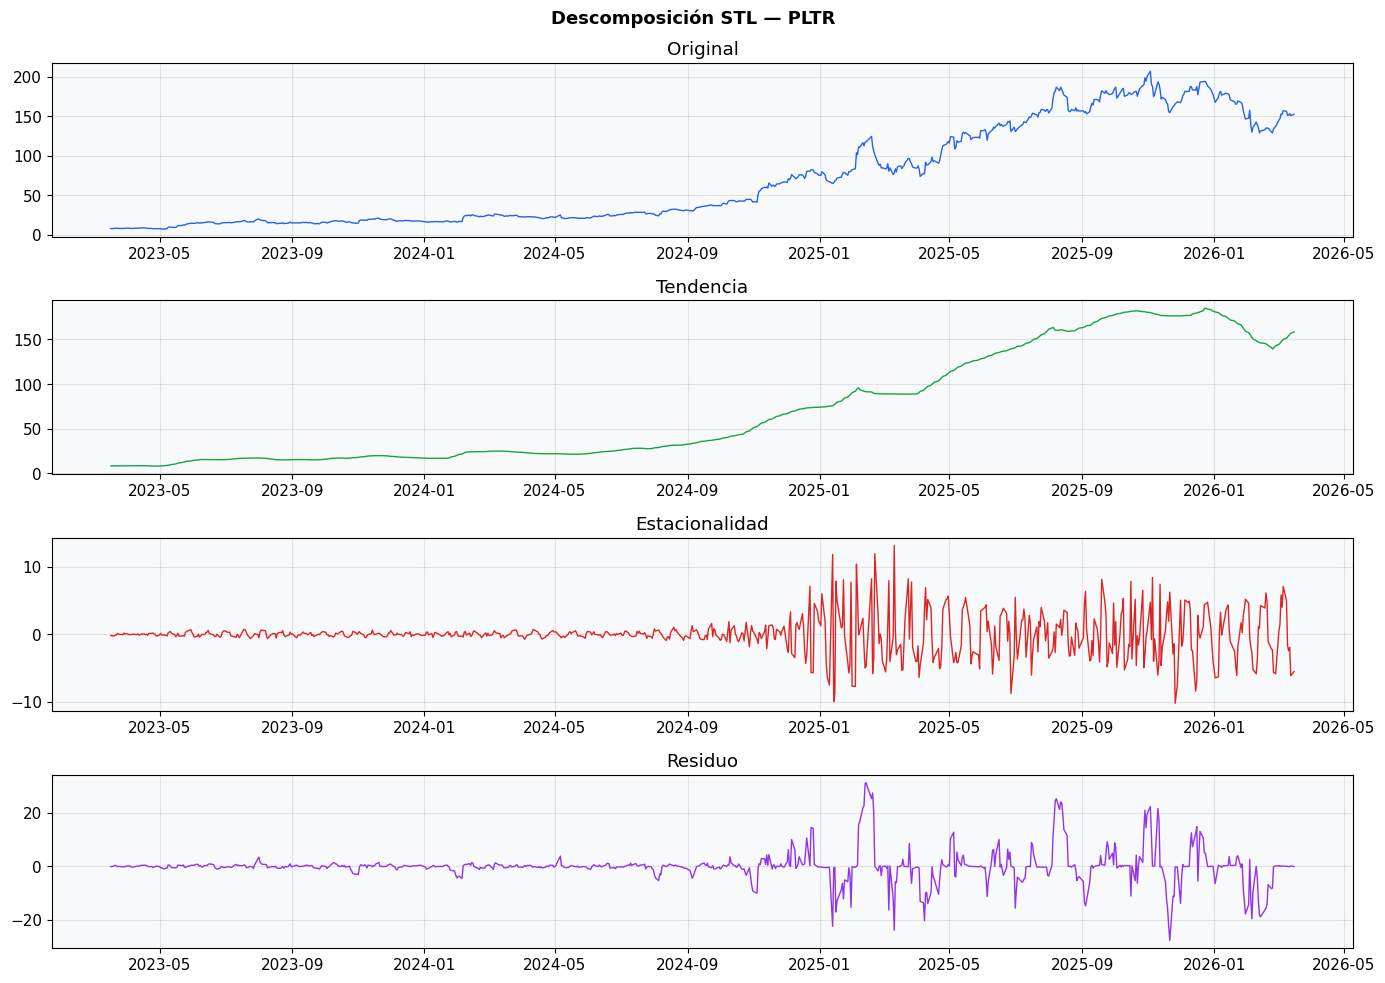


📌 Fuerza estacional: 0.170
⚪ La serie NO tiene estacionalidad fuerte
   → No es necesario modelo estacional


In [27]:
def analizar_estacionalidad(serie, periodo=None):
    """
    Detecta automáticamente si la serie tiene componente estacional.
    periodo: None = auto-detectar, o pasar un entero (7=semanal, 12=mensual, etc.)
    """
    # Auto-detectar frecuencia
    if periodo is None:
        freq = pd.infer_freq(serie.index)
        freq_map = {'D': 7, 'W': 52, 'M': 12, 'MS': 12, 'Q': 4, 'QS': 4, 'A': 1, 'H': 24}
        periodo = next((v for k, v in freq_map.items() if freq and freq.startswith(k)), 12)
        print(f'Frecuencia detectada: {freq} → periodo estacional = {periodo}')

    if periodo <= 1 or len(serie) < periodo * 2:
        print('⚠️  Serie muy corta o frecuencia no detectada para descomposición estacional.')
        return False, None

    try:
        stl = STL(serie, period=periodo, robust=True)
        res = stl.fit()

        # Fuerza estacional: qué % de la varianza explica la estacionalidad
        var_seasonal  = np.var(res.seasonal)
        var_residual  = np.var(res.resid)
        fuerza_estac  = max(0, 1 - var_residual / (var_seasonal + var_residual))
        tiene_estac   = fuerza_estac > 0.30  # umbral empírico

        fig, axes = plt.subplots(4, 1, figsize=(14, 10))
        fig.suptitle(f'Descomposición STL — {serie.name}', fontsize=13, fontweight='bold')
        colores = ['#2563eb', '#16a34a', '#dc2626', '#9333ea']
        etiquetas = ['Original', 'Tendencia', 'Estacionalidad', 'Residuo']
        componentes = [serie, res.trend, res.seasonal, res.resid]

        for ax, comp, col, etiq in zip(axes, componentes, colores, etiquetas):
            ax.plot(comp, color=col, linewidth=1)
            ax.set_title(etiq)
            ax.set_ylabel('')

        plt.tight_layout()
        plt.show()

        print(f'\n📌 Fuerza estacional: {fuerza_estac:.3f}')
        if tiene_estac:
            print(f'✅ La serie TIENE componente estacional significativa (periodo={periodo})')
            print(f'   → Considerar SARIMA(p,d,q)(P,D,Q)[{periodo}] o Prophet')
        else:
            print(f'⚪ La serie NO tiene estacionalidad fuerte')
            print(f'   → No es necesario modelo estacional')

        return tiene_estac, periodo
    except Exception as e:
        print(f'⚠️  No se pudo descomponer: {e}')
        return False, None

tiene_estacionalidad, periodo_estac = analizar_estacionalidad(serie)

## 6. ACF y PACF — Identificación del modelo

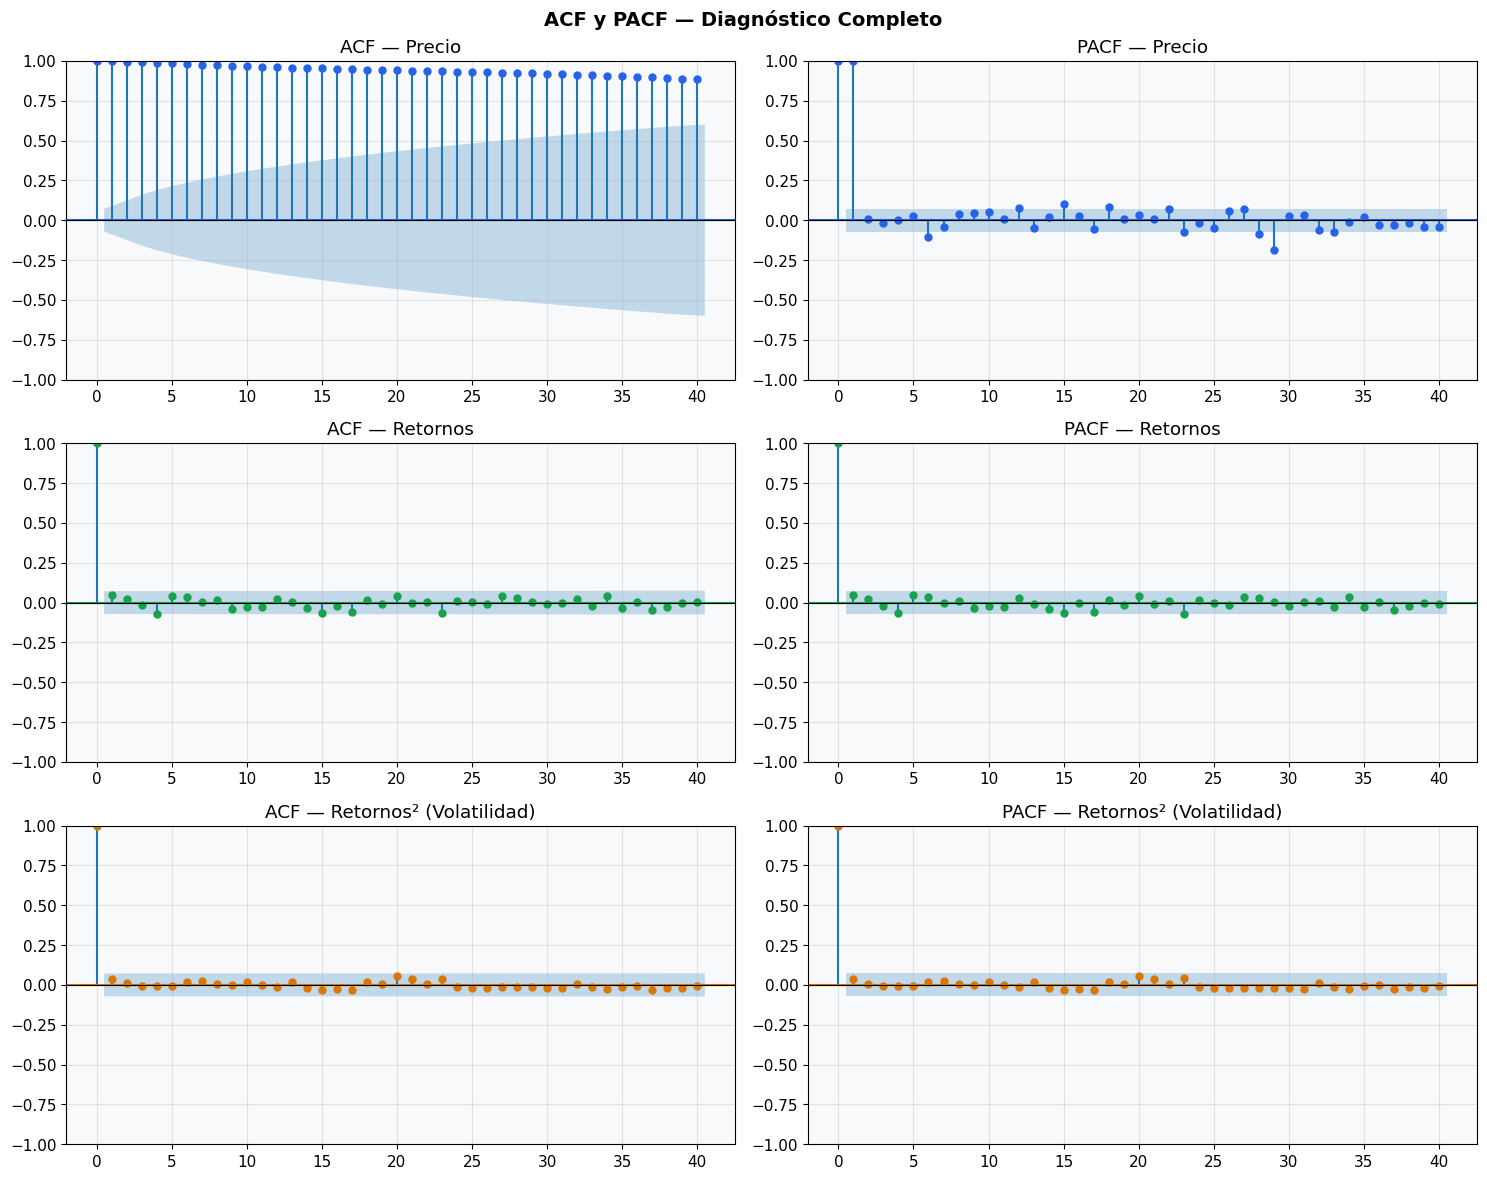


--- Lectura automática de ACF/PACF sobre retornos ---
Patrón detectado: RUIDO_BLANCO
Lags ACF significativos: 0 | Lags PACF significativos: 0
Orden sugerido: p=0, q=0


In [28]:
def plot_acf_pacf_completo(serie, retornos, lags=40):
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    fig.suptitle('ACF y PACF — Diagnóstico Completo', fontsize=14, fontweight='bold')

    series_plot = [
        (serie,            'Precio',                '#2563eb'),
        (retornos,         'Retornos',              '#16a34a'),
        (retornos**2,      'Retornos² (Volatilidad)','#d97706'),
    ]

    for i, (s, nombre, color) in enumerate(series_plot):
        s_clean = s.dropna()
        plot_acf( s_clean, lags=lags, ax=axes[i,0], color=color, title=f'ACF — {nombre}',  zero=True)
        plot_pacf(s_clean, lags=lags, ax=axes[i,1], color=color, title=f'PACF — {nombre}', zero=True)
        for ax in axes[i]:
            ax.axhline(0, color='black', linewidth=0.8)

    plt.tight_layout()
    plt.show()

def leer_acf_pacf(serie, lags=20, alpha=0.05):
    """
    Analiza los valores de ACF y PACF para sugerir el orden del modelo.
    Retorna: (p_sugerido, q_sugerido, patron)
    """
    acf_vals,  confint_acf  = acf( serie.dropna(), nlags=lags, alpha=alpha)
    pacf_vals, confint_pacf = pacf(serie.dropna(), nlags=lags, alpha=alpha)

    # Umbrales de significancia
    ci_acf  = confint_acf[1:,1]  - acf_vals[1:]
    ci_pacf = confint_pacf[1:,1] - pacf_vals[1:]

    sig_acf  = np.where(np.abs(acf_vals[1:])  > ci_acf,  1, 0)
    sig_pacf = np.where(np.abs(pacf_vals[1:]) > ci_pacf, 1, 0)

    # Primer lag donde deja de ser significativo (corte)
    def primer_corte(sig_arr):
        for i, v in enumerate(sig_arr):
            if v == 0:
                return i  # lag i+1 es el primero no significativo
        return len(sig_arr)  # todos significativos

    corte_acf  = primer_corte(sig_acf)
    corte_pacf = primer_corte(sig_pacf)
    total_sig_acf  = sig_acf.sum()
    total_sig_pacf = sig_pacf.sum()

    # Decaimiento: ¿cuántos lags siguen siendo significativos?
    acf_lento  = total_sig_acf  > lags * 0.5
    pacf_lento = total_sig_pacf > lags * 0.5

    # Patrón
    if acf_lento and not pacf_lento:
        patron = 'AR'
        p = min(corte_pacf + 1, 5)
        q = 0
    elif not acf_lento and pacf_lento:
        patron = 'MA'
        p = 0
        q = min(corte_acf + 1, 5)
    elif acf_lento and pacf_lento:
        patron = 'ARMA'
        p = min(corte_pacf + 1, 3)
        q = min(corte_acf  + 1, 3)
    else:
        patron = 'RUIDO_BLANCO'
        p = 0
        q = 0

    return p, q, patron, total_sig_acf, total_sig_pacf

plot_acf_pacf_completo(serie, retornos)

print('\n--- Lectura automática de ACF/PACF sobre retornos ---')
p, q, patron, n_acf, n_pacf = leer_acf_pacf(retornos)
print(f'Patrón detectado: {patron}')
print(f'Lags ACF significativos: {n_acf} | Lags PACF significativos: {n_pacf}')
print(f'Orden sugerido: p={p}, q={q}')

## 7. Test de Ruido Blanco — Ljung-Box

In [29]:
def test_ruido_blanco(serie, nombre='Serie', lags=[5, 10, 20]):
    print(f"\n{'='*55}")
    print(f'  TEST LJUNG-BOX (Ruido Blanco) — {nombre}')
    print(f"{'='*55}")
    print(f'  H0: La serie es ruido blanco (no hay autocorrelación)')
    print(f"{'─'*55}")

    lb = acorr_ljungbox(serie.dropna(), lags=lags, return_df=True)
    es_ruido = True
    for lag in lags:
        row = lb.loc[lag]
        sig = '❌ HAY estructura' if row['lb_pvalue'] < 0.05 else '✅ Ruido blanco'
        if row['lb_pvalue'] < 0.05:
            es_ruido = False
        print(f'  Lag {lag:2d}: Q={row["lb_stat"]:.3f}  p={row["lb_pvalue"]:.4f}  →  {sig}')

    print(f"{'─'*55}")
    if es_ruido:
        print(f'  RESULTADO: ✅ Ruido blanco — sin estructura en media')
    else:
        print(f'  RESULTADO: ❌ No es ruido blanco — hay estructura modelable')
    print(f"{'='*55}\n")
    return es_ruido

es_ruido_retornos = test_ruido_blanco(retornos, nombre='Retornos')


  TEST LJUNG-BOX (Ruido Blanco) — Retornos
  H0: La serie es ruido blanco (no hay autocorrelación)
───────────────────────────────────────────────────────
  Lag  5: Q=6.815  p=0.2348  →  ✅ Ruido blanco
  Lag 10: Q=9.849  p=0.4539  →  ✅ Ruido blanco
  Lag 20: Q=20.257  p=0.4419  →  ✅ Ruido blanco
───────────────────────────────────────────────────────
  RESULTADO: ✅ Ruido blanco — sin estructura en media



## 8. Test de Efecto ARCH — ¿Hay agrupación de volatilidad?

In [30]:
def test_arch(retornos, lags=[5, 10, 20]):
    from statsmodels.stats.diagnostic import het_arch

    print(f"\n{'='*55}")
    print(f'  TEST DE EFECTOS ARCH (Engle)')
    print(f"{'='*55}")
    print(f'  H0: No hay efectos ARCH (varianza constante)')
    print(f"{'─'*55}")

    r_clean = retornos.dropna()
    hay_arch = False
    for lag in lags:
        lm_stat, lm_pval, f_stat, f_pval = het_arch(r_clean, nlags=lag)
        sig = '✅ ARCH detectado' if lm_pval < 0.05 else '⚪ Sin efecto ARCH'
        if lm_pval < 0.05:
            hay_arch = True
        print(f'  Lag {lag:2d}: LM={lm_stat:.3f}  p={lm_pval:.4f}  →  {sig}')

    print(f"{'─'*55}")
    if hay_arch:
        print(f'  RESULTADO: ✅ Efecto ARCH significativo → Usar GARCH')
    else:
        print(f'  RESULTADO: ⚪ Sin efecto ARCH → Varianza constante')
    print(f"{'='*55}\n")
    return hay_arch

hay_arch = test_arch(retornos)


  TEST DE EFECTOS ARCH (Engle)
  H0: No hay efectos ARCH (varianza constante)
───────────────────────────────────────────────────────
  Lag  5: LM=1.079  p=0.9560  →  ⚪ Sin efecto ARCH
  Lag 10: LM=1.928  p=0.9969  →  ⚪ Sin efecto ARCH
  Lag 20: LM=6.588  p=0.9978  →  ⚪ Sin efecto ARCH
───────────────────────────────────────────────────────
  RESULTADO: ⚪ Sin efecto ARCH → Varianza constante



## 9. Análisis de Normalidad y Colas


  ANÁLISIS DISTRIBUCIONAL DE RETORNOS
  Curtosis (exceso):  8.8875  (Normal = 0)
  Asimetría:          1.3700  (Normal = 0)
  Jarque-Bera:        stat=2703.01  p=0.0000
  ❌ Distribución NO normal
  ⚠️  Colas pesadas (leptocúrtica) → considerar distribución t de Student en GARCH
  ⚠️  Asimetría notable → considerar distribución GED o skew-t en GARCH



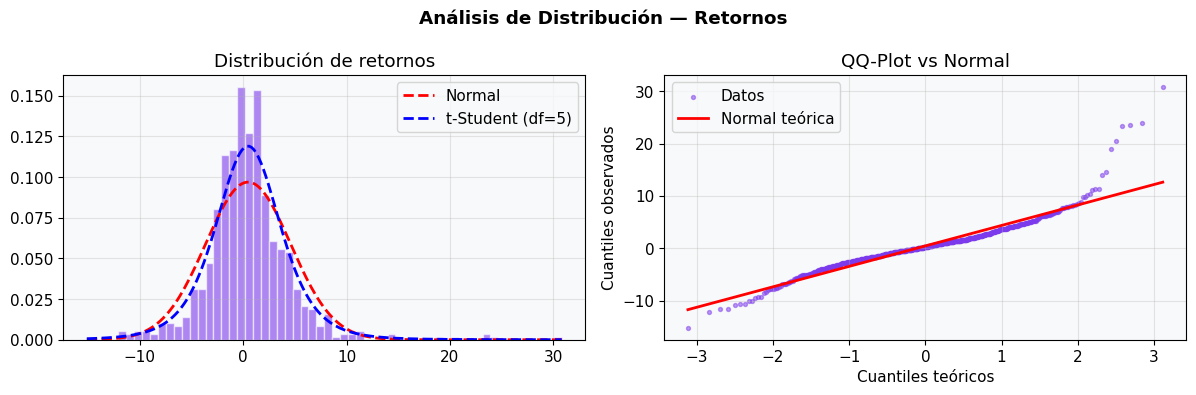

In [31]:
def analisis_distribucional(retornos):
    # Aplanar a array 1D (fix para yfinance MultiIndex / Series 2D)
    r = retornos.dropna()
    if hasattr(r, 'values'):
        r_arr = r.values.flatten().astype(float)
    else:
        r_arr = np.array(r).flatten().astype(float)
    r_arr = r_arr[~np.isnan(r_arr)]

    # float() garantiza escalar aunque scipy devuelva array
    kurt   = float(stats.kurtosis(r_arr))
    skew_v = float(stats.skew(r_arr))
    jb_stat, jb_p = stats.jarque_bera(r_arr)
    jb_stat, jb_p = float(jb_stat), float(jb_p)

    print(f"\n{'='*55}")
    print(f'  ANÁLISIS DISTRIBUCIONAL DE RETORNOS')
    print(f"{'='*55}")
    print(f'  Curtosis (exceso):  {kurt:.4f}  (Normal = 0)')
    print(f'  Asimetría:          {skew_v:.4f}  (Normal = 0)')
    print(f'  Jarque-Bera:        stat={jb_stat:.2f}  p={jb_p:.4f}')

    if jb_p < 0.05:
        print(f'  ❌ Distribución NO normal')
    else:
        print(f'  ✅ No se rechaza normalidad')

    if kurt > 1:
        print(f'  ⚠️  Colas pesadas (leptocúrtica) → considerar distribución t de Student en GARCH')

    if abs(skew_v) > 0.5:
        print(f'  ⚠️  Asimetría notable → considerar distribución GED o skew-t en GARCH')

    print(f"{'='*55}\n")

    # Gráficos
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Análisis de Distribución — Retornos', fontweight='bold')

    # Histograma — usar r_arr (numpy 1D) para evitar errores de matplotlib
    axes[0].hist(r_arr, bins=60, density=True, color='#7c3aed', alpha=0.6, edgecolor='white')
    xr = np.linspace(r_arr.min(), r_arr.max(), 200)
    axes[0].plot(xr, stats.norm.pdf(xr, r_arr.mean(), r_arr.std()),
                 'r--', lw=2, label='Normal')
    axes[0].plot(xr, stats.t.pdf(xr, df=5, loc=r_arr.mean(),
                 scale=r_arr.std() * np.sqrt(3/5)),
                 'b--', lw=2, label='t-Student (df=5)')
    axes[0].legend()
    axes[0].set_title('Distribución de retornos')

    # QQ-plot manual — probplot necesita array 1D limpio
    (osm, osr), (slope, intercept, _) = stats.probplot(r_arr, dist='norm')
    axes[1].scatter(osm, osr, color='#7c3aed', s=8, alpha=0.5, label='Datos')
    axes[1].plot(osm, slope * np.array(osm) + intercept, 'r-', lw=2, label='Normal teórica')
    axes[1].set_title('QQ-Plot vs Normal')
    axes[1].set_xlabel('Cuantiles teóricos')
    axes[1].set_ylabel('Cuantiles observados')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return kurt, skew_v

curtosis, asimetria = analisis_distribucional(retornos)

## 10. Selección automática de orden ARIMA — Auto-AIC/BIC

In [32]:
def seleccion_arima(serie_estac, max_p=4, max_q=4, criterio='aic'):
    """
    Grid search sobre (p,q) para ARIMA. Solo si la serie tiene estructura en media.
    """
    print(f"\n{'='*55}")
    print(f'  BÚSQUEDA DE MEJOR ORDEN ARIMA (max_p={max_p}, max_q={max_q})')
    print(f'  Criterio: {criterio.upper()}')
    print(f"{'='*55}")

    mejor_score = np.inf
    mejor_orden = (0, 0)
    resultados  = []

    for p in range(0, max_p + 1):
        for q in range(0, max_q + 1):
            if p == 0 and q == 0:
                continue
            try:
                modelo = ARIMA(serie_estac.dropna(), order=(p, 0, q))
                fit    = modelo.fit()
                score  = getattr(fit, criterio)
                resultados.append({'p': p, 'q': q, criterio: round(score, 2)})
                if score < mejor_score:
                    mejor_score = score
                    mejor_orden = (p, q)
            except:
                pass

    df_res = pd.DataFrame(resultados).sort_values(criterio).head(10)
    print(df_res.to_string(index=False))
    print(f'\n  ✅ MEJOR ORDEN: ARMA({mejor_orden[0]}, {mejor_orden[1]})  |  {criterio.upper()} = {mejor_score:.2f}')
    print(f"{'='*55}\n")
    return mejor_orden

# Solo ejecutar si los retornos no son ruido blanco
if not es_ruido_retornos:
    mejor_arma = seleccion_arima(retornos)
else:
    print('ℹ️  Retornos = ruido blanco. No se busca orden ARMA.')
    mejor_arma = (0, 0)

ℹ️  Retornos = ruido blanco. No se busca orden ARMA.


## 11. Ajuste del modelo GARCH (si hay efecto ARCH)

In [33]:
def ajustar_garch(retornos, p=1, q=1, dist='normal'):
    """
    Ajusta GARCH(p,q) y muestra resultados.
    dist: 'normal', 't', 'skewt', 'ged'
    """
    r_scaled = retornos.dropna() * 100  # escalar para estabilidad numérica

    modelo = arch_model(r_scaled, vol='Garch', p=p, q=q, dist=dist, mean='Zero')
    res    = modelo.fit(disp='off')

    print(res.summary())

    # Gráfico de volatilidad condicional
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle(f'Modelo GARCH({p},{q}) — Volatilidad Condicional', fontweight='bold')

    axes[0].plot(retornos.dropna(), color='#16a34a', linewidth=0.8, alpha=0.8)
    axes[0].set_title('Retornos')
    axes[0].axhline(0, color='black', lw=0.8)

    vol_cond = res.conditional_volatility / 100
    axes[1].plot(vol_cond, color='#dc2626', linewidth=1)
    axes[1].fill_between(vol_cond.index, 0, vol_cond, alpha=0.2, color='#dc2626')
    axes[1].set_title('Volatilidad Condicional (σ_t)')

    plt.tight_layout()
    plt.show()

    # Diagnóstico de residuos estandarizados
    resid_std = res.std_resid
    lb_resid  = acorr_ljungbox(resid_std, lags=[10], return_df=True)
    lb_resid2 = acorr_ljungbox(resid_std**2, lags=[10], return_df=True)
    print(f'\n📌 Diagnóstico de residuos GARCH:')
    print(f'   Ljung-Box residuos   (p): {lb_resid["lb_pvalue"].values[0]:.4f}  ')
    print( f"""{'✅ OK' if lb_resid["lb_pvalue"].values[0] > 0.05 else "❌ Aún hay autocorrelación"}""")
    print(f'   Ljung-Box residuos²  (p): {lb_resid2["lb_pvalue"].values[0]:.4f}  ')
    print(f'{"✅ Efecto ARCH eliminado" if lb_resid2["lb_pvalue"].values[0] > 0.05 else "⚠️ Aún queda efecto ARCH"}')
    return res

if hay_arch:
    # Elegir distribución según curtosis
    dist_garch = 't' if curtosis > 1 else 'normal'
    print(f'\nUsando distribución: {dist_garch} (curtosis={curtosis:.2f})')
    res_garch = ajustar_garch(retornos, p=1, q=1, dist=dist_garch)
else:
    print('ℹ️  No se detectó efecto ARCH. No se ajusta GARCH.')

ℹ️  No se detectó efecto ARCH. No se ajusta GARCH.


## 12. 🏆 Diagnóstico Final y Recomendación

In [34]:
def recomendacion_final(es_estacionaria_precio, es_estacionaria_retornos,
                         es_ruido_retornos, hay_arch, tiene_estacionalidad,
                         periodo_estac, mejor_arma, curtosis, asimetria):

    print('\n' + '█'*62)
    print('  🏆  DIAGNÓSTICO FINAL Y RECOMENDACIÓN DE MODELO')
    print('█'*62)

    print('\n  RESUMEN DE DIAGNÓSTICOS:')
    print(f"  {'─'*50}")
    print(f"  Precio estacionario:        {'✅' if es_estacionaria_precio   else '❌'}")
    print(f"  Retornos estacionarios:     {'✅' if es_estacionaria_retornos else '❌'}")
    print(f"  Retornos = ruido blanco:    {'✅' if es_ruido_retornos        else '❌'}")
    print(f"  Efecto ARCH en volatilidad: {'✅' if hay_arch                 else '❌'}")
    print(f"  Estacionalidad detectada:   {'✅' if tiene_estacionalidad     else '❌'}")
    print(f"  Curtosis elevada (>1):      {'✅' if curtosis > 1            else '❌'}")
    print(f"  {'─'*50}")

    recomendaciones = []
    descartados     = []

    # --- Lógica de decisión ---

    # 1. Precio: siempre descartar modelar directamente si no es estacionario
    if not es_estacionaria_precio:
        descartados.append('ARIMA sobre precio — No estacionario (requiere diferenciación)')
    
    # 2. Retornos
    if es_ruido_retornos:
        descartados.append('ARIMA sobre retornos — Son ruido blanco (no hay estructura en media)')
    else:
        p, q = mejor_arma
        if tiene_estacionalidad and periodo_estac:
            recomendaciones.append(f'SARIMA({p},1,{q})(P,D,Q)[{periodo_estac}] — Estructura en media + estacionalidad')
        else:
            recomendaciones.append(f'ARIMA({p},1,{q}) — Hay estructura en media de retornos')

    # 3. Volatilidad
    if hay_arch:
        dist_rec = 't' if curtosis > 1 else 'normal'
        skew_rec = ' (con asimetría → dist. skew-t)' if abs(asimetria) > 0.5 else ''
        recomendaciones.append(f'GARCH(1,1) con dist. {dist_rec}{skew_rec} — Clustering de volatilidad detectado')
        if not es_ruido_retornos:
            recomendaciones.append(f'ARMA-GARCH: modela media y varianza simultáneamente')
    else:
        descartados.append('GARCH — Sin efecto ARCH (varianza constante)')

    # 4. Estacionalidad sin estructura en media
    if tiene_estacionalidad and es_ruido_retornos:
        recomendaciones.append(f'Prophet / TBATS — Estacionalidad detectada pero sin estructura ARMA')

    # 5. Series largas con múltiples estacionalidades
    if len(serie) > 1000:
        recomendaciones.append('Prophet — Serie larga, puede capturar tendencias y estacionalidades complejas')

    print('\n  ❌ MODELOS DESCARTADOS:')
    for d in descartados:
        print(f'     • {d}')

    print('\n  ✅ MODELOS RECOMENDADOS (en orden de prioridad):')
    for i, r in enumerate(recomendaciones, 1):
        print(f'     {i}. {r}')

    print('\n  📝 PRÓXIMOS PASOS:')
    if hay_arch:
        print('     1. Ajustar GARCH(1,1) → revisar residuos estandarizados')
        print('     2. Comparar AIC entre GARCH(1,1), EGARCH(1,1) y GJR-GARCH(1,1)')
        print('        (EGARCH/GJR capturan efecto apalancamiento: caídas generan más volatilidad)')
        print('     3. Usar volatilidad condicional para VaR o pricing de opciones')
    if not es_ruido_retornos:
        print(f'     • Validar ARIMA con walk-forward cross-validation')

    print('\n' + '█'*62 + '\n')

recomendacion_final(
    es_estacionaria_precio   = es_estacionaria_precio,
    es_estacionaria_retornos = es_estacionaria_retornos,
    es_ruido_retornos        = es_ruido_retornos,
    hay_arch                 = hay_arch,
    tiene_estacionalidad     = tiene_estacionalidad,
    periodo_estac            = periodo_estac,
    mejor_arma               = mejor_arma,
    curtosis                 = curtosis,
    asimetria                = asimetria
)


██████████████████████████████████████████████████████████████
  🏆  DIAGNÓSTICO FINAL Y RECOMENDACIÓN DE MODELO
██████████████████████████████████████████████████████████████

  RESUMEN DE DIAGNÓSTICOS:
  ──────────────────────────────────────────────────
  Precio estacionario:        ❌
  Retornos estacionarios:     ✅
  Retornos = ruido blanco:    ✅
  Efecto ARCH en volatilidad: ❌
  Estacionalidad detectada:   ❌
  Curtosis elevada (>1):      ✅
  ──────────────────────────────────────────────────

  ❌ MODELOS DESCARTADOS:
     • ARIMA sobre precio — No estacionario (requiere diferenciación)
     • ARIMA sobre retornos — Son ruido blanco (no hay estructura en media)
     • GARCH — Sin efecto ARCH (varianza constante)

  ✅ MODELOS RECOMENDADOS (en orden de prioridad):

  📝 PRÓXIMOS PASOS:

██████████████████████████████████████████████████████████████



## 13. Bonus — Comparación de variantes GARCH
Si quieres ir más allá del GARCH estándar:

In [35]:
def comparar_garch_variantes(retornos):
    """
    Compara GARCH, EGARCH y GJR-GARCH por AIC/BIC.
    EGARCH y GJR capturan el efecto apalancamiento (leverage effect):
    las malas noticias generan más volatilidad que las buenas.
    """
    if not hay_arch:
        print('ℹ️  Sin efecto ARCH — comparación de variantes GARCH no aplica.')
        return

    r_scaled = retornos.dropna() * 100
    dist_garch = 't' if curtosis > 1 else 'normal'

    variantes = [
        ('GARCH(1,1)',    arch_model(r_scaled, vol='Garch',  p=1, q=1, dist=dist_garch, mean='Zero')),
        ('EGARCH(1,1)',   arch_model(r_scaled, vol='EGARCH', p=1, q=1, dist=dist_garch, mean='Zero')),
        ('GJR-GARCH(1,1)',arch_model(r_scaled, vol='GARCH',  p=1, o=1, q=1, dist=dist_garch, mean='Zero')),
    ]

    print(f"\n{'='*55}")
    print(f'  COMPARACIÓN DE VARIANTES GARCH (dist={dist_garch})')
    print(f"{'='*55}")
    print(f"  {'Modelo':<20} {'AIC':>10} {'BIC':>10} {'Log-L':>12}")
    print(f"  {'─'*52}")

    resultados = []
    for nombre, modelo in variantes:
        try:
            fit = modelo.fit(disp='off')
            resultados.append((nombre, fit.aic, fit.bic, fit.loglikelihood))
            print(f'  {nombre:<20} {fit.aic:>10.2f} {fit.bic:>10.2f} {fit.loglikelihood:>12.2f}')
        except Exception as e:
            print(f'  {nombre:<20} Error: {e}')

    if resultados:
        mejor = min(resultados, key=lambda x: x[1])  # menor AIC
        print(f"  {'─'*52}")
        print(f'  ✅ Mejor modelo por AIC: {mejor[0]}')
    print(f"{'='*55}\n")

comparar_garch_variantes(retornos)

ℹ️  Sin efecto ARCH — comparación de variantes GARCH no aplica.


---
## 📊 Referencia Rápida — Patrones ACF/PACF

| ACF | PACF | Modelo |
|-----|------|--------|
| Baja lento | Se corta en lag p | AR(p) |
| Se corta en lag q | Baja lento | MA(q) |
| Baja lento | Baja lento | ARMA(p,q) |
| Muy persistente (casi 1) | Se corta en lag 1 | Serie con raíz unitaria → Diferenciar |
| Pico en lag estacional | Pico en lag estacional | SARIMA |
| Casi nula | Casi nula | Ruido blanco |

## 🧭 Árbol de Decisión

```
¿Serie estacionaria?
  NO → Diferenciar → ¿Estacional? → SARIMA / ARIMA(d>0)
  SÍ → ¿ACF/PACF muestran estructura?
         SÍ → AR / MA / ARMA
         NO → Ruido Blanco → ¿Retornos²  autocorrelados?
                               SÍ → GARCH / EGARCH / GJR-GARCH
                               NO → Sin modelo (o Prophet para tendencias suaves)
```

## 14. Modelos ML — Múltiples Horizontes de Predicción

Cuando ARIMA y GARCH no aplican, exploramos modelos no lineales sobre **múltiples horizontes** simultáneamente.

```
HORIZONTES = [1, 5, 21]   # días hacia adelante
             t+1 = mañana
             t+5 = próxima semana
             t+21= próximo mes
```

Para cada horizonte `h` el target es:
```python
target_h = precio.pct_change(h).shift(-h)  # retorno acumulado en h días
```

| Modelo | Ventaja | Limitación |
|--------|---------|------------|
| **LSTM** | Captura dependencias secuenciales largas | Lento, necesita muchos datos |
| **Random Forest** | Robusto, no sobreajusta fácil | Menos potente en patrones complejos |
| **XGBoost** | Generalmente el más preciso | Requiere tuning cuidadoso |

### 14.0 Instalación

In [37]:
# !pip install tensorflow scikit-learn xgboost -q
print('✅ Dependencias ML instaladas')

✅ Dependencias ML instaladas


### 14.1 Configuración — Cambia aquí los horizontes

In [38]:
# ============================================================
#  CONFIGURACIÓN PRINCIPAL
#  Modifica estos valores según tu análisis
# ============================================================

HORIZONTES   = [1, 5, 21]    # días: t+1 (diario), t+5 (semanal), t+21 (mensual)
N_LAGS       = 20             # cuántos lags de retornos usar como features
TEST_SIZE    = 0.20           # fracción de datos para test (siempre al final)
LSTM_EPOCHS  = 80             # máximo de épocas (EarlyStopping suele cortar antes)
LSTM_UNITS   = [64, 32]       # neuronas por capa LSTM
TIMESTEPS    = 20             # ventana de secuencia para LSTM

print(f'Horizontes configurados: {HORIZONTES} días')
print(f'Test set: últimos {TEST_SIZE*100:.0f}% de la serie')

Horizontes configurados: [1, 5, 21] días
Test set: últimos 20% de la serie


### 14.2 Construcción de Features

In [39]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

def _to_series(x):
    """Garantiza Series 1D limpia — fix para yfinance MultiIndex/DataFrame."""
    if isinstance(x, pd.DataFrame):
        x = x.iloc[:, 0]
    if hasattr(x, 'values'):
        arr = x.values.flatten().astype(float)
    else:
        arr = np.array(x, dtype=float).flatten()
    return pd.Series(arr, index=x.index[:len(arr)], name=getattr(x, 'name', 'value'))

def construir_features(serie, n_lags=20):
    """
    Features comunes para todos los horizontes.
    El target varía por horizonte — se construye aparte.
    """
    s = _to_series(serie)   # <-- siempre 1D
    df = pd.DataFrame(index=s.index)
    ret = s.pct_change()

    # Lags de retornos diarios
    for lag in range(1, n_lags + 1):
        df[f'lag_{lag}'] = ret.shift(lag)

    # Medias móviles y volatilidad rolling
    for w in [5, 10, 20, 50]:
        df[f'ma_{w}']  = ret.rolling(w).mean()
        df[f'std_{w}'] = ret.rolling(w).std()

    # Momentum multi-período
    for w in [5, 10, 21]:
        df[f'mom_{w}'] = s.pct_change(w)

    # RSI (14 días)
    delta = s.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    df['rsi_14'] = 100 - (100 / (1 + gain / (loss + 1e-9)))

    feature_cols = list(df.columns)
    return df, feature_cols, ret

def construir_target(serie, h):
    """Retorno acumulado en h días hacia adelante — siempre devuelve Series 1D."""
    s = _to_series(serie)
    target = s.pct_change(h).shift(-h)
    target.name = f'target_h{h}'
    return target

def preparar_datos(df_features, serie, h, test_size, feature_cols):
    """Combina features + target para horizonte h y hace split temporal."""
    target = construir_target(serie, h)

    df = df_features.copy()
    # Alinear índices por si hay diferencia de longitud
    idx_comun = df.index.intersection(target.index)
    df = df.loc[idx_comun]
    target = target.loc[idx_comun]

    df['target'] = target.values   # .values evita conflictos de índice
    df = df.dropna()

    X = df[feature_cols]
    y = df['target']

    split = int(len(X) * (1 - test_size))
    return X.iloc[:split], X.iloc[split:], y.iloc[:split], y.iloc[split:]

# Construir features base (sin target aún)
df_features, feature_cols, ret = construir_features(serie, n_lags=N_LAGS)
print(f'✅ Features base: {len(feature_cols)} columnas')
print(f'   {feature_cols[:8]} ...')

✅ Features base: 32 columnas
   ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8'] ...


### 14.3 Funciones de entrenamiento

In [40]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

def preparar_datos(df_features, serie, h, test_size, feature_cols):
    """Combina features + target para horizonte h y hace split temporal."""
    target = construir_target(serie, h).rename(f'target_h{h}')
    df = df_features.copy()
    df['target'] = target
    df = df.dropna()

    X = df[feature_cols]
    y = df['target']

    split = int(len(X) * (1 - test_size))
    return X.iloc[:split], X.iloc[split:], y.iloc[:split], y.iloc[split:]


def metricas(real, pred, nombre):
    rmse    = float(np.sqrt(mean_squared_error(real, pred)))
    mae     = float(mean_absolute_error(real, pred))
    dir_acc = float(np.mean(np.sign(pred) == np.sign(real)) * 100)
    return {'modelo': nombre, 'rmse': rmse, 'mae': mae, 'dir_acc': dir_acc}


def entrenar_rf(X_tr, y_tr, X_te, y_te, scaler):
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_te)
    rf = RandomForestRegressor(n_estimators=300, max_depth=8,
                                min_samples_leaf=5, n_jobs=-1, random_state=42)
    rf.fit(X_tr_sc, y_tr)
    pred = rf.predict(X_te_sc)
    return pred, rf


def entrenar_xgb(X_tr, y_tr, X_te, y_te, scaler):
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_te)
    model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=5,
                              subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
                              random_state=42, verbosity=0)
    model.fit(X_tr_sc, y_tr, eval_set=[(X_te_sc, y_te)], verbose=False)
    pred = model.predict(X_te_sc)
    return pred, model


def entrenar_lstm(X_tr, y_tr, X_te, y_te, timesteps, epochs, units):
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_tr_sc  = scaler_X.fit_transform(X_tr)
    X_te_sc  = scaler_X.transform(X_te)
    y_tr_sc  = scaler_y.fit_transform(y_tr.values.reshape(-1,1)).flatten()

    def make_seq(X, y, ts):
        Xs, ys = [], []
        for i in range(ts, len(X)):
            Xs.append(X[i-ts:i])
            ys.append(y[i])
        return np.array(Xs), np.array(ys)

    X_tr_seq, y_tr_seq = make_seq(X_tr_sc, y_tr_sc, timesteps)
    X_te_seq, _        = make_seq(X_te_sc, np.zeros(len(X_te_sc)), timesteps)

    tf.random.set_seed(42)
    model = Sequential([
        Input(shape=(timesteps, X_tr_seq.shape[2])),
        LSTM(units[0], return_sequences=True), Dropout(0.2),
        LSTM(units[1], return_sequences=False), Dropout(0.2),
        Dense(16, activation='relu'), Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')

    cbs = [EarlyStopping(patience=15, restore_best_weights=True, verbose=0),
           ReduceLROnPlateau(patience=7, factor=0.5, verbose=0)]
    model.fit(X_tr_seq, y_tr_seq, validation_split=0.15,
              epochs=epochs, batch_size=32, callbacks=cbs, verbose=0)

    pred_sc = model.predict(X_te_seq, verbose=0).flatten()
    pred    = scaler_y.inverse_transform(pred_sc.reshape(-1,1)).flatten()
    # real alineado con la ventana LSTM
    real_aligned = y_te.values[timesteps:]
    return pred, real_aligned, model

print('✅ Funciones de entrenamiento definidas')

✅ Funciones de entrenamiento definidas


### 14.4 Loop principal — Entrenar los 3 modelos × cada horizonte

In [41]:
# Almacena todos los resultados
todos_resultados = []   # lista de dicts {horizonte, modelo, rmse, mae, dir_acc}
predicciones     = {}   # {(h, modelo): (idx, pred, real)}

for h in HORIZONTES:
    print(f"\n{'='*55}")
    print(f'  HORIZONTE t+{h} — retorno acumulado en {h} día(s)')
    print(f"{'='*55}")

    X_tr, X_te, y_tr, y_te = preparar_datos(
        df_features, serie, h, TEST_SIZE, feature_cols
    )
    print(f'  Train: {len(X_tr)} obs | Test: {len(X_te)} obs')

    scaler = StandardScaler()

    # ── Random Forest ─────────────────────────────────────
    pred_rf, rf_m = entrenar_rf(X_tr, y_tr, X_te, y_te, StandardScaler())
    m_rf = metricas(y_te.values, pred_rf, 'Random Forest')
    m_rf['horizonte'] = h
    todos_resultados.append(m_rf)
    predicciones[(h, 'Random Forest')] = (y_te.index, pred_rf, y_te.values)
    print(f'  RF   — RMSE: {m_rf["rmse"]:.5f} | Dir.Acc: {m_rf["dir_acc"]:.1f}%')

    # ── XGBoost ───────────────────────────────────────────
    pred_xgb, xgb_m = entrenar_xgb(X_tr, y_tr, X_te, y_te, StandardScaler())
    m_xgb = metricas(y_te.values, pred_xgb, 'XGBoost')
    m_xgb['horizonte'] = h
    todos_resultados.append(m_xgb)
    predicciones[(h, 'XGBoost')] = (y_te.index, pred_xgb, y_te.values)
    print(f'  XGB  — RMSE: {m_xgb["rmse"]:.5f} | Dir.Acc: {m_xgb["dir_acc"]:.1f}%')

    # ── LSTM ──────────────────────────────────────────────
    pred_lstm, real_lstm, lstm_m_obj = entrenar_lstm(
        X_tr, y_tr, X_te, y_te, TIMESTEPS, LSTM_EPOCHS, LSTM_UNITS
    )
    m_lstm = metricas(real_lstm, pred_lstm, 'LSTM')
    m_lstm['horizonte'] = h
    todos_resultados.append(m_lstm)
    idx_lstm = y_te.index[TIMESTEPS:]
    predicciones[(h, 'LSTM')] = (idx_lstm, pred_lstm, real_lstm)
    print(f'  LSTM — RMSE: {m_lstm["rmse"]:.5f} | Dir.Acc: {m_lstm["dir_acc"]:.1f}%')

print(f"\n✅ Entrenamiento completo — {len(todos_resultados)} combinaciones modelo×horizonte")


  HORIZONTE t+1 — retorno acumulado en 1 día(s)
  Train: 560 obs | Test: 140 obs
  RF   — RMSE: 0.03495 | Dir.Acc: 50.7%
  XGB  — RMSE: 0.04018 | Dir.Acc: 52.9%


2026-03-16 16:11:27.109782: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-03-16 16:11:27.382795: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2026-03-16 16:11:27.385045: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2026-03-16 16:11:27.386512: I tensorflow/core/com

2026-03-16 16:11:32.520166: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2026-03-16 16:11:32.522391: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2026-03-16 16:11:32.523932: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

  LSTM — RMSE: 0.03901 | Dir.Acc: 53.3%

  HORIZONTE t+5 — retorno acumulado en 5 día(s)
  Train: 556 obs | Test: 140 obs
  RF   — RMSE: 0.09658 | Dir.Acc: 50.0%
  XGB  — RMSE: 0.14669 | Dir.Acc: 47.1%


2026-03-16 16:11:41.544221: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2026-03-16 16:11:41.546422: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2026-03-16 16:11:41.547824: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

2026-03-16 16:11:51.162584: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2026-03-16 16:11:51.164362: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2026-03-16 16:11:51.165487: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

  LSTM — RMSE: 0.12287 | Dir.Acc: 36.7%

  HORIZONTE t+21 — retorno acumulado en 21 día(s)
  Train: 544 obs | Test: 136 obs
  RF   — RMSE: 0.27450 | Dir.Acc: 44.9%
  XGB  — RMSE: 0.26252 | Dir.Acc: 44.9%


2026-03-16 16:11:52.634593: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2026-03-16 16:11:52.635627: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2026-03-16 16:11:52.636853: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

2026-03-16 16:12:00.694232: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2026-03-16 16:12:00.696379: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2026-03-16 16:12:00.698390: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

  LSTM — RMSE: 0.25917 | Dir.Acc: 45.7%

✅ Entrenamiento completo — 9 combinaciones modelo×horizonte


### 14.5 Visualización — Predicciones por horizonte

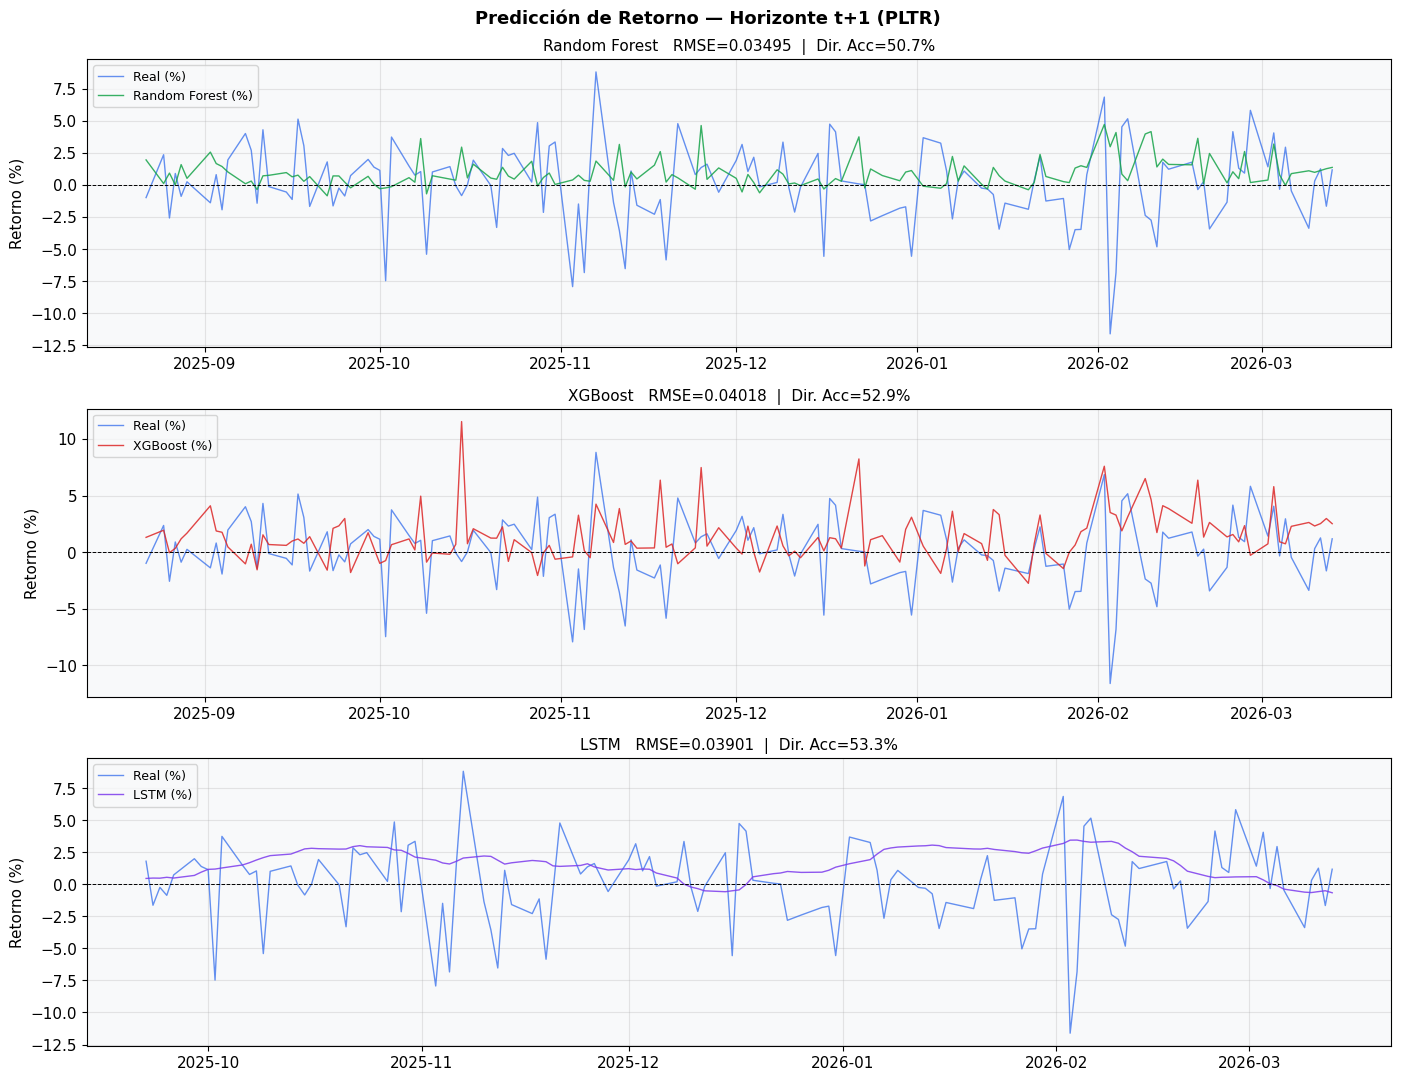

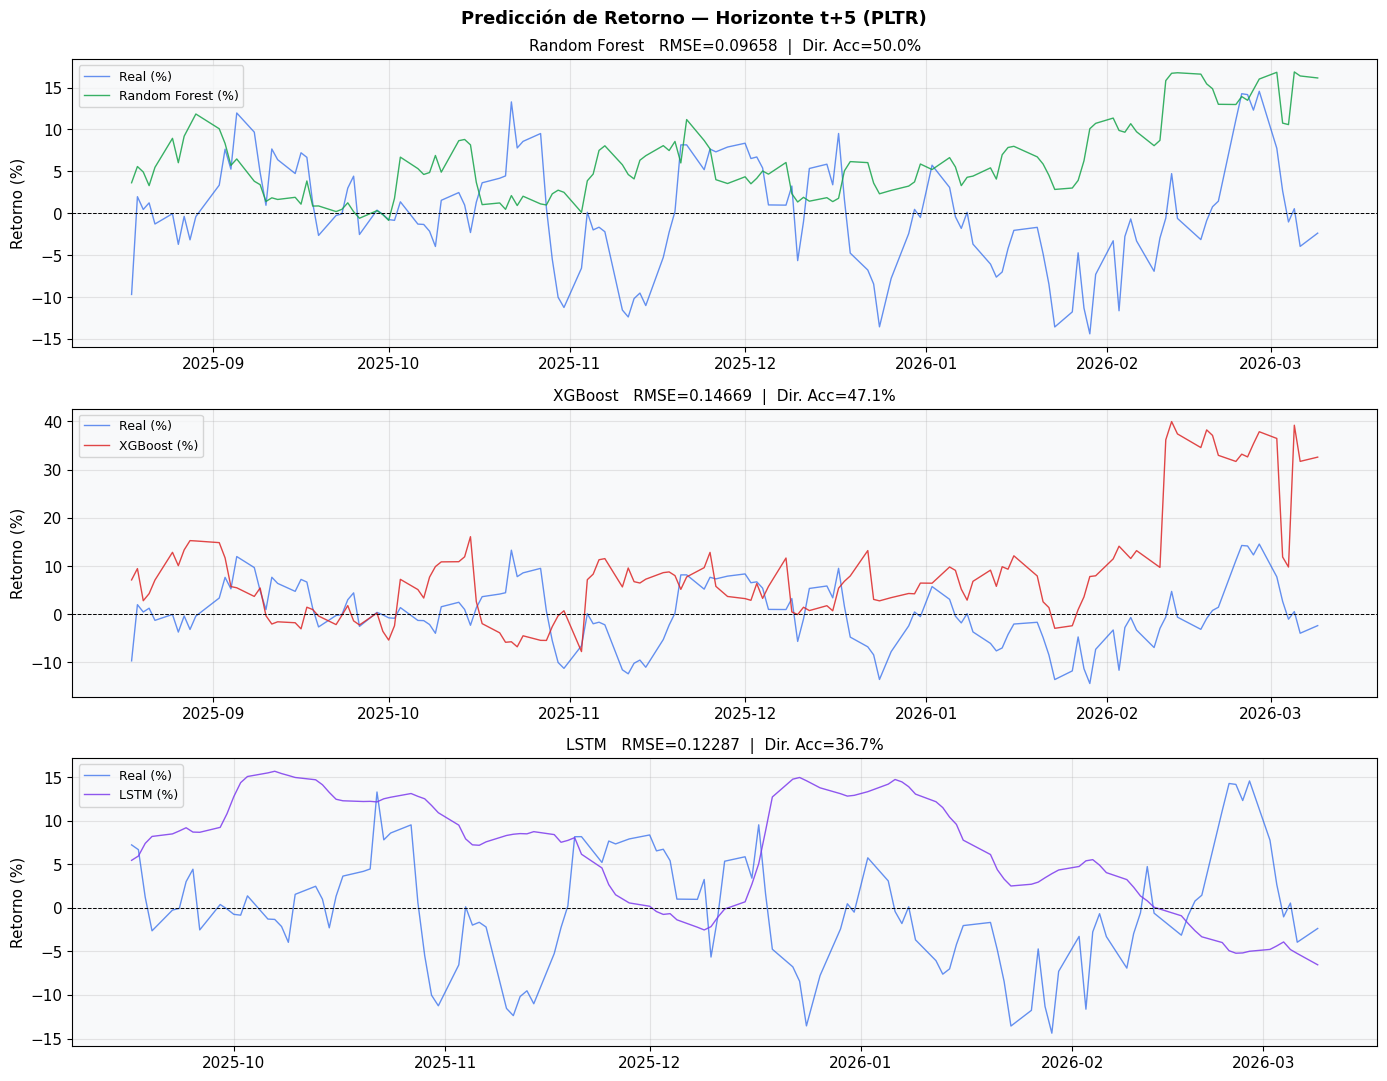

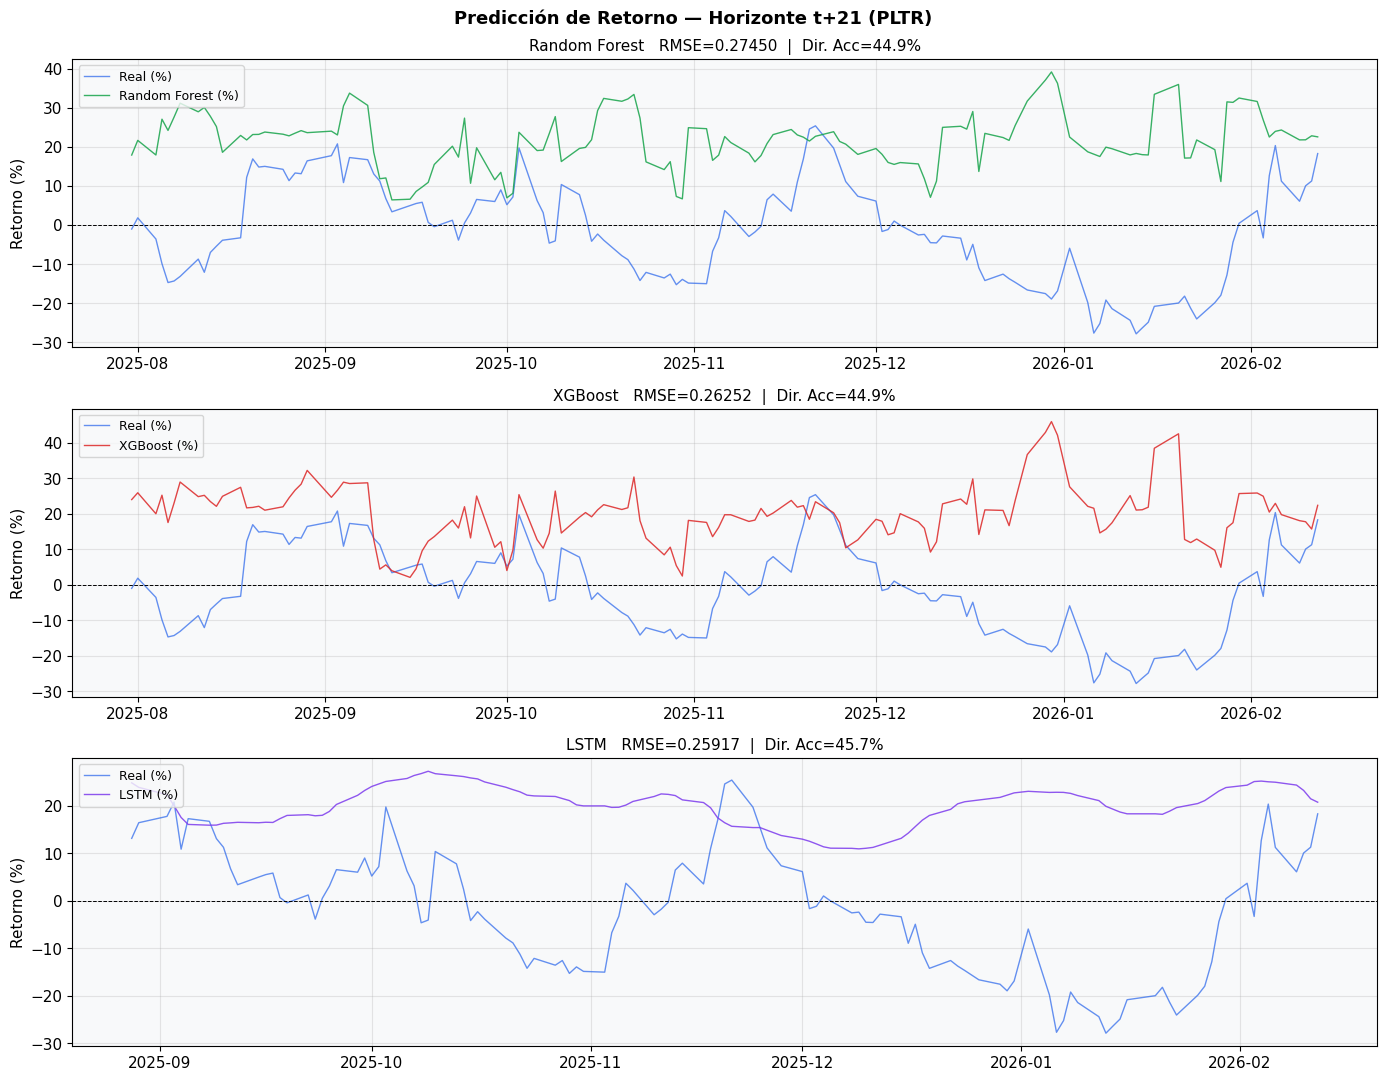

In [42]:
colores = {'Random Forest': '#16a34a', 'XGBoost': '#dc2626', 'LSTM': '#7c3aed'}

for h in HORIZONTES:
    fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)
    fig.suptitle(
        f'Predicción de Retorno — Horizonte t+{h} ({serie.name})',
        fontsize=13, fontweight='bold'
    )

    for ax, modelo in zip(axes, ['Random Forest', 'XGBoost', 'LSTM']):
        idx, pred, real = predicciones[(h, modelo)]
        ax.plot(idx, real * 100, label='Real (%)',       color='#2563eb', lw=1, alpha=0.7)
        ax.plot(idx, pred * 100, label=f'{modelo} (%)', color=colores[modelo], lw=1, alpha=0.85)
        ax.axhline(0, color='black', lw=0.7, linestyle='--')
        m = next(r for r in todos_resultados if r['horizonte']==h and r['modelo']==modelo)
        ax.set_title(
            f'{modelo}   RMSE={m["rmse"]:.5f}  |  Dir. Acc={m["dir_acc"]:.1f}%',
            fontsize=11
        )
        ax.set_ylabel('Retorno (%)')
        ax.legend(loc='upper left', fontsize=9)

    plt.tight_layout()
    plt.show()

### 14.6 Tabla resumen y heatmap comparativo


█████████████████████████████████████████████████████████████████
  📊  TABLA RESUMEN — RETORNO (%) × MODELO × HORIZONTE
█████████████████████████████████████████████████████████████████
                     dir_acc                                      rmse                             
horizonte_label t+1 (diario) t+21 (mensual) t+5 (semanal) t+1 (diario) t+21 (mensual) t+5 (semanal)
modelo                                                                                             
LSTM                 53.3333        45.6897       36.6667       0.0390         0.2592        0.1229
Random Forest        50.7143        44.8529       50.0000       0.0349         0.2745        0.0966
XGBoost              52.8571        44.8529       47.1429       0.0402         0.2625        0.1467
█████████████████████████████████████████████████████████████████



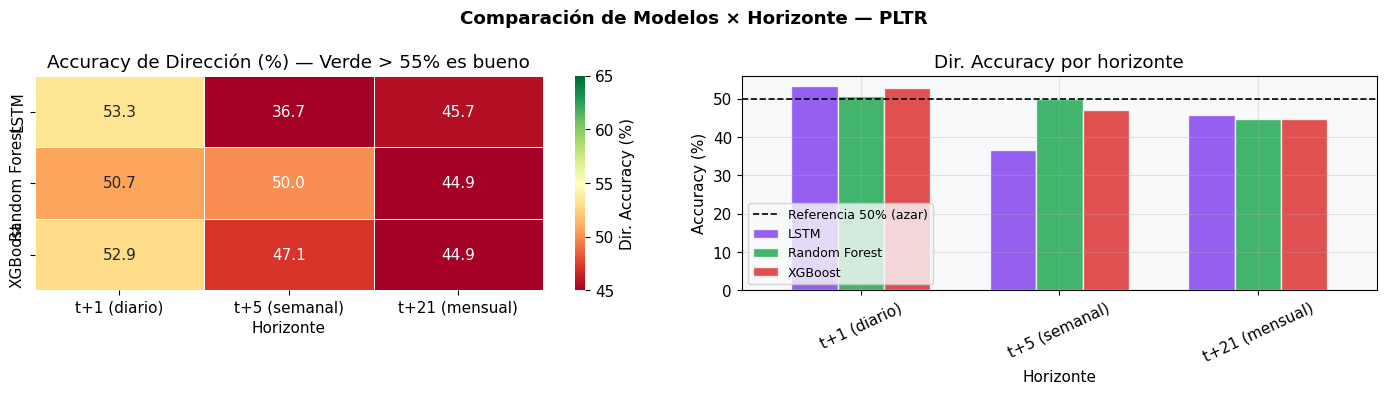


  🏆  MEJOR MODELO POR HORIZONTE:
  ─────────────────────────────────────────────
  t+1 (diario)          LSTM              53.3%  ⚠️ 
  t+5 (semanal)         Random Forest     50.0%  ⚠️ 
  t+21 (mensual)        LSTM              45.7%  ⚠️ 
  ─────────────────────────────────────────────
  ✅ > 55% = valor predictivo real
  ⚠️  ≈ 50% = equivalente a azar



In [43]:
df_res = pd.DataFrame(todos_resultados)[['horizonte','modelo','rmse','mae','dir_acc']]
df_res['horizonte_label'] = df_res['horizonte'].map({1:'t+1 (diario)', 5:'t+5 (semanal)', 21:'t+21 (mensual)'})

print(f"\n{'█'*65}")
print(f'  📊  TABLA RESUMEN — RETORNO (%) × MODELO × HORIZONTE')
print(f"{'█'*65}")
tabla = df_res.pivot_table(
    index='modelo', columns='horizonte_label',
    values=['dir_acc','rmse'], aggfunc='first'
)
print(tabla.round(4).to_string())
print(f"{'█'*65}\n")

# ── Heatmap de Dir. Accuracy ──────────────────────────────
pivot_acc = df_res.pivot(index='modelo', columns='horizonte_label', values='dir_acc')

# Ordenar columnas cronológicamente
orden_cols = [c for c in ['t+1 (diario)','t+5 (semanal)','t+21 (mensual)'] if c in pivot_acc.columns]
pivot_acc  = pivot_acc[orden_cols]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f'Comparación de Modelos × Horizonte — {serie.name}', fontweight='bold')

import seaborn as sns

# Heatmap accuracy dirección
sns.heatmap(pivot_acc, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=45, vmax=65, ax=axes[0], linewidths=0.5,
            cbar_kws={'label': 'Dir. Accuracy (%)'})
axes[0].set_title('Accuracy de Dirección (%) — Verde > 55% es bueno')
axes[0].set_xlabel('Horizonte')
axes[0].set_ylabel('')

# Bar chart comparativo por horizonte
pivot_acc.T.plot(kind='bar', ax=axes[1],
                 color=[colores[m] for m in pivot_acc.index],
                 alpha=0.8, edgecolor='white', width=0.7)
axes[1].axhline(50, color='black', lw=1.2, linestyle='--', label='Referencia 50% (azar)')
axes[1].set_title('Dir. Accuracy por horizonte')
axes[1].set_xlabel('Horizonte')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=25)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Conclusión automática ─────────────────────────────────
print("\n  🏆  MEJOR MODELO POR HORIZONTE:")
print(f"  {'─'*45}")
for hl in orden_cols:
    sub  = df_res[df_res['horizonte_label'] == hl].sort_values('dir_acc', ascending=False)
    best = sub.iloc[0]
    emoji = '✅' if best['dir_acc'] > 55 else '⚠️ '
    print(f"  {hl:<20}  {best['modelo']:<16}  {best['dir_acc']:.1f}%  {emoji}")
print(f"  {'─'*45}")
print("  ✅ > 55% = valor predictivo real")
print("  ⚠️  ≈ 50% = equivalente a azar\n")

### 14.7 Feature Importance — ¿Qué lags importan más?

XGBoost nos dice qué features tienen más poder predictivo para cada horizonte — útil para entender si el mercado tiene memoria en el corto o largo plazo.

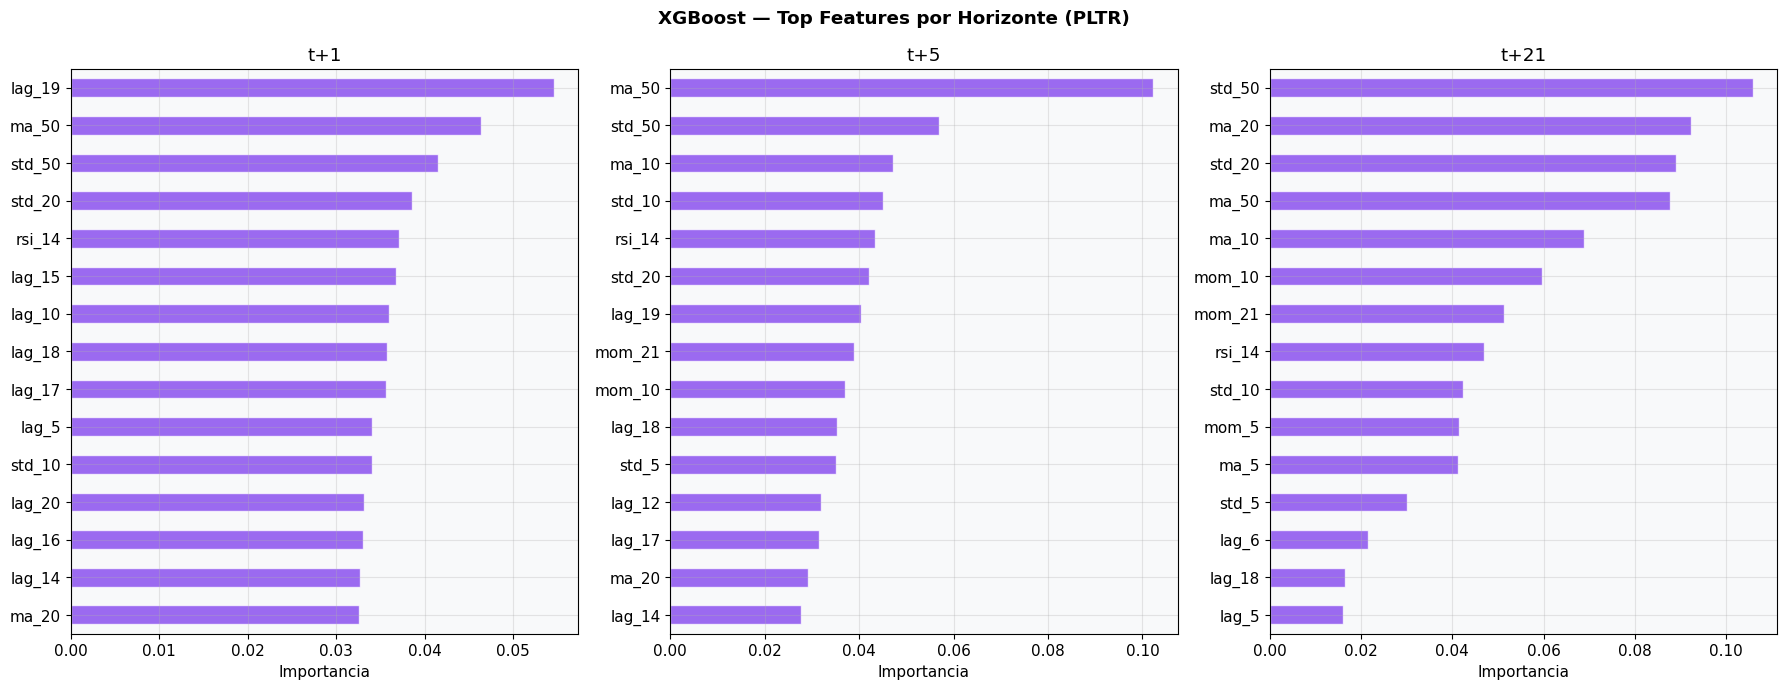

In [44]:
# Re-entrenar XGBoost guardando modelos por horizonte
xgb_modelos = {}

for h in HORIZONTES:
    X_tr, X_te, y_tr, y_te = preparar_datos(
        df_features, serie, h, TEST_SIZE, feature_cols
    )
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_te)
    model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=5,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=42, verbosity=0)
    model.fit(X_tr_sc, y_tr, eval_set=[(X_te_sc, y_te)], verbose=False)
    xgb_modelos[h] = model

# Gráfico de importancias por horizonte
fig, axes = plt.subplots(1, len(HORIZONTES), figsize=(6*len(HORIZONTES), 7))
if len(HORIZONTES) == 1:
    axes = [axes]
fig.suptitle(f'XGBoost — Top Features por Horizonte ({serie.name})', fontweight='bold')

for ax, h in zip(axes, HORIZONTES):
    imp = pd.Series(xgb_modelos[h].feature_importances_, index=feature_cols)
    top = imp.sort_values(ascending=True).tail(15)
    top.plot(kind='barh', ax=ax, color='#7c3aed', alpha=0.75, edgecolor='white')
    ax.set_title(f't+{h}')
    ax.set_xlabel('Importancia')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()